# 线性垂向动力学

无论是设计阶段的阻尼筒选型、传递比设计，还是试车阶段的阻尼调校初始值，这些都需要我们建立一台车的垂向动力学模型进行定量分析，并进行优化。
## 指标体系概述
一台车悬架的理想状态是什么呢？或者说，如果我有一套理想的主动悬架，可以瞬间输出任何大小的力，它的控制目标应该是什么呢？

汽车在不平整的路面上行驶，会有颠簸，即使是FSAE赛道一般的机场跑道，也并不是光滑的平面。那么在车轮被激发上下运动的过程中，其一定会出现轮荷变化。此外，在车辆不断地加速变向的过程中，车身的惯性力变化（觉得惯性力是错误表述的高中生玩泥巴去，别来看这个）也会引发轮荷转移，而这个轮荷转移的过程平滑与否，是否过冲，也会造成轮荷的变化。

根据简单公式 $F_{xy} = \mu F_z$, 轮胎的抓地力会随着Fz的变化而变化，我们称之为静态损失。除此之外，还有与振动频率和轮胎松弛长度相关的动态损失，在此先按下不表。在某个周期变化的轮荷下，车手无法根据轮荷瞬间改变自己的踏板输入（但是TC算法没准可以（手动狗头）），所以我们可以得出以下结论：**轮荷的变化越小越好**。

具体到FSAE，由于路面较为平滑，所以绝大多数悬架输入都来来源于车身动态，所以**在FSAE赛事的独特工况中，车身动态可以代轮荷变化量的主要成分**。

那么，我们要如何描述车身动态的特性呢？我们知道，方程式赛车的刹车压力曲线初段近似于一个阶跃函数。而一个弹簧质量阻尼类型系统的阶跃响应可以使用阻尼比 $\zeta$ 表示。阶跃响应与 $\zeta$ 的关系如下图所示：


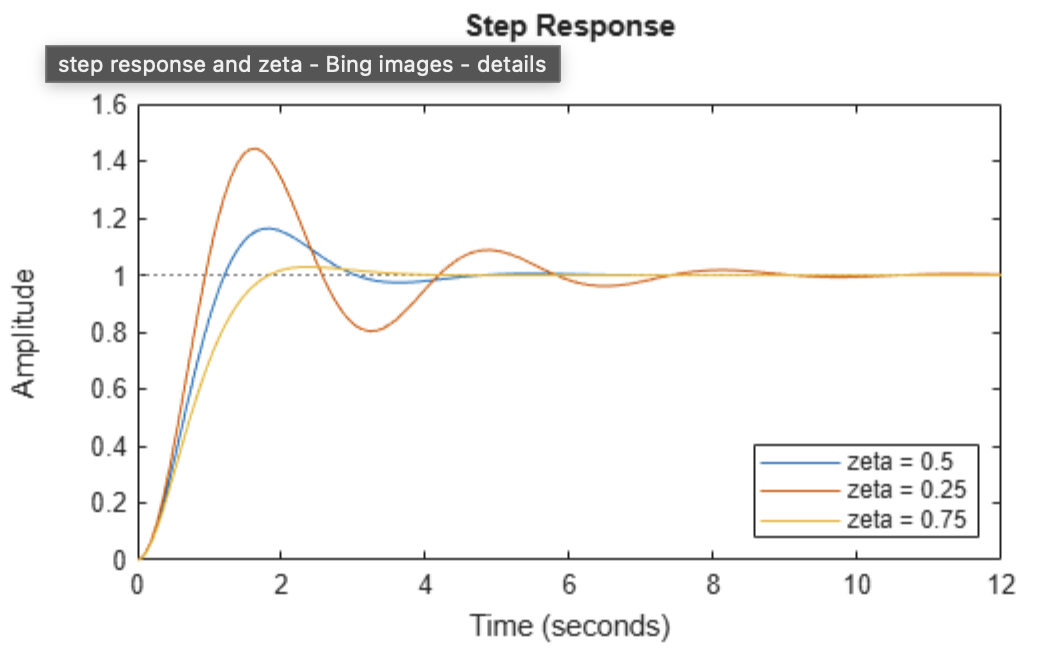

从中不难看出，当阻尼比小于1的时候，系统会产生过冲和震荡。那么可知，既然车身动态可以描述轮荷变化的主要成分，而车身的阶跃响应余震又可以用阻尼比 $\zeta$ 来描述，我们**只需要尽可能提高车身的阻尼比**，就可以大致判断出最优阻尼系数的范围。

## 数学模型

车身的垂向运动有三个模态：
- 垂移 (heave)：车身在z轴上平移
- 俯仰 (pitch): 车身绕y轴旋转
- 横滚/侧倾 (roll): 车身绕x轴旋转

【简述模态阻尼比概念】

在FSAE的实际运用中，由于横滚模态及其与横摆动力学耦合的特性常被用于调节整车的横摆响应，将不纳入客观性能体系，而针对驾控方面优化。因此，我们感兴趣的模态便只剩下了俯仰和垂移。于是，为了建模方便，可以将一台车砍半，得到如下半车垂向动力学模型：

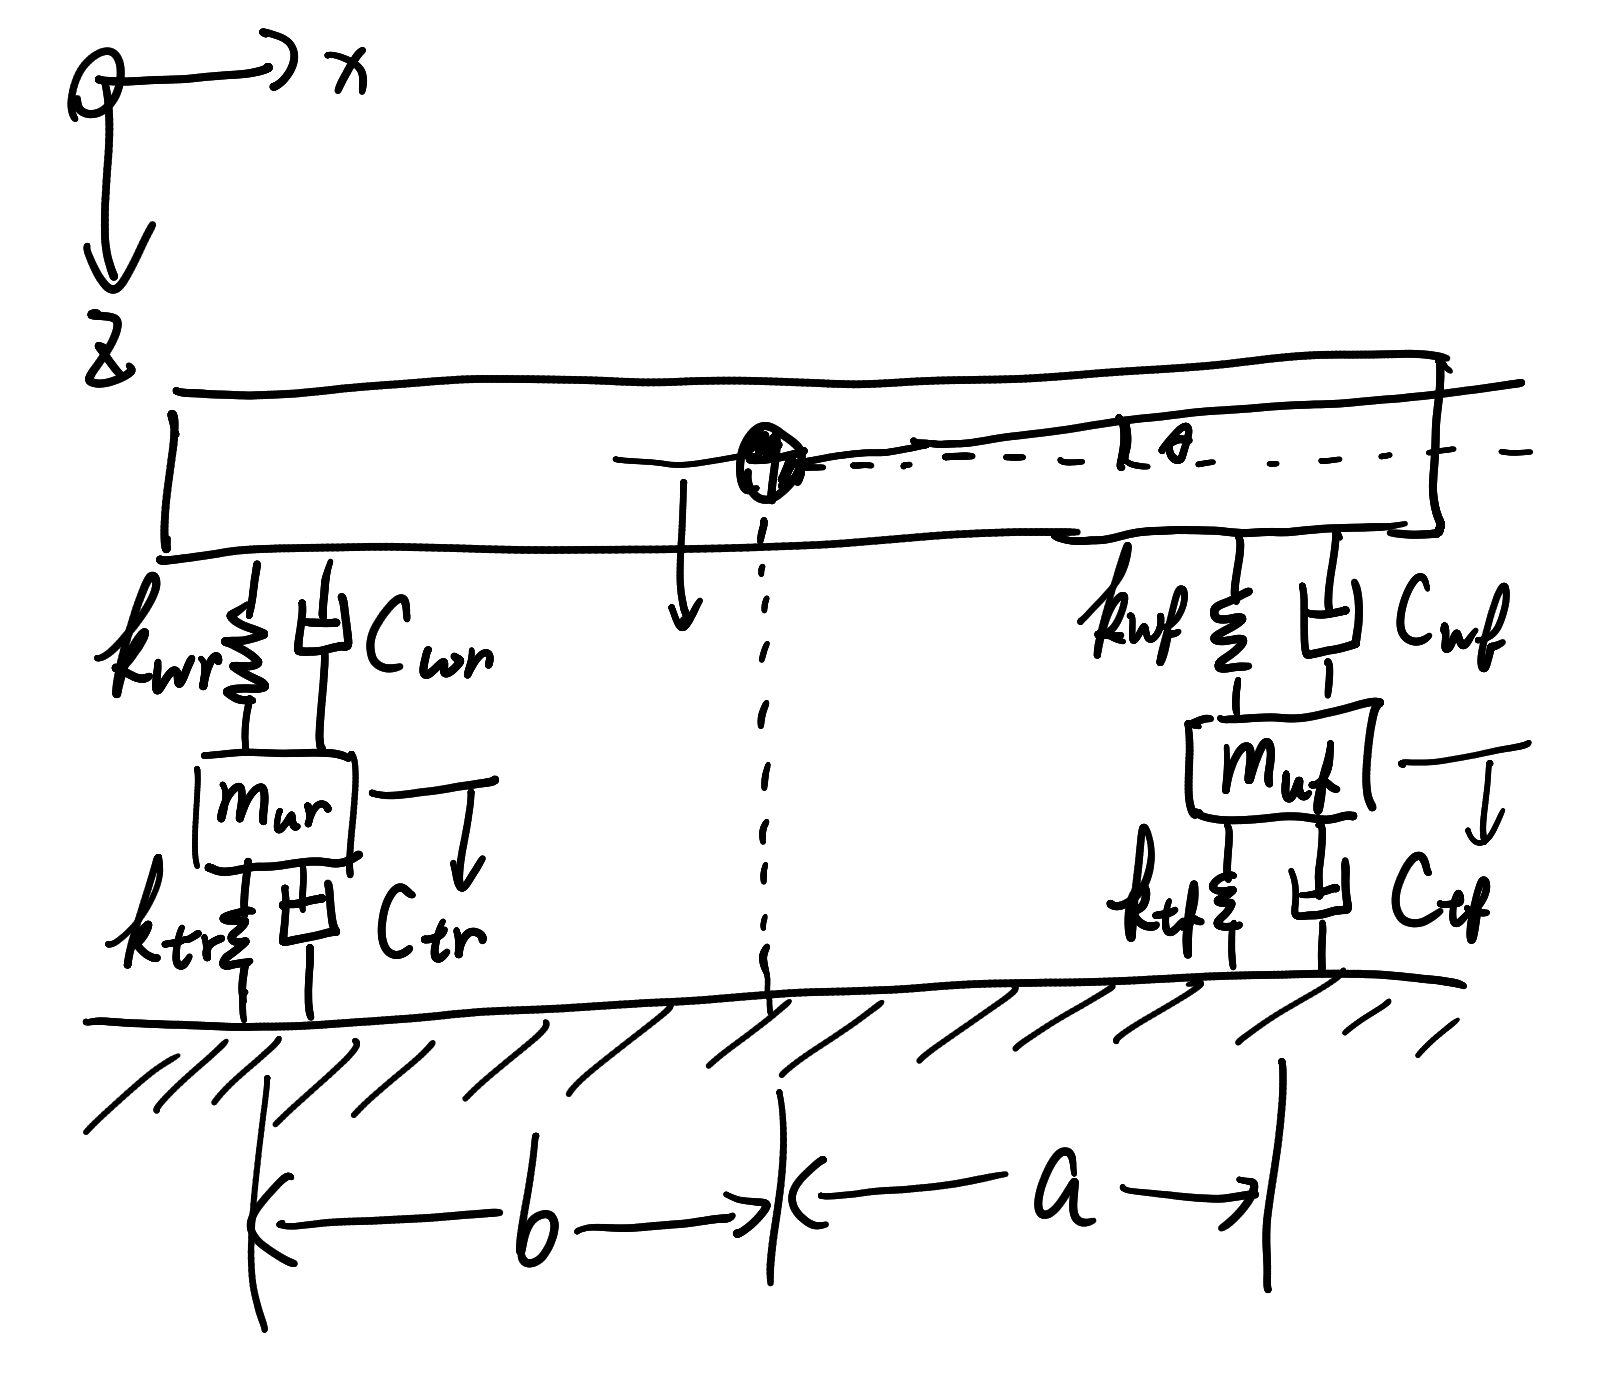

如前文所述，我们需要了解这个系统的模态阻尼比，最好的工具就是多数机械振动课程中教授的线性振动模态分析。对该半车垂向动力学模型推导运动方程的状态空间A矩阵，并利用矩阵特征值法便可求得偏频和阻尼比。

### 运动方程推导

首先，输入变量值：

In [62]:
import numpy as np

# ===== XJ_Racing 参数 =====
m_uf = m_ur = 8.0          # 单轮簧下质量 [kg]
m_s = 46.0 + 58.0          # 半车簧上质量 [kg]
r = 0.38                   # 俯仰回转半径 [m]

c_wf = 1000.0              # 前避震阻尼 [Ns/m]
c_wr = 1000.0              # 后避震阻尼 [Ns/m]

c_tf = c_tr = 0.0                       # 轮胎阻尼
k_tf = k_tr = 150000.0                  # 轮胎垂直刚度 [N/m]

# wheel_rate = spring_rate / MR^2
k_wf = 114.4 / (1.73**2) * 1000        # 前 [N/m]
k_wr =  79.2 / (1.58**2) * 1000        # 后 [N/m]

cg_x = 0.45                # 前轴质量占比
l = 1.545                  # 轴距 [m]

b = l * cg_x
a = l * (1 - cg_x)
I_yy = m_s * r**2

print(f"XJ_Racing: m_s={m_s:.0f}kg, k_wf={k_wf/1000:.1f}N/mm, k_wr={k_wr/1000:.1f}N/mm")
print(f"  a={a:.3f}m, b={b:.3f}m, I_yy={I_yy:.1f}kg.m2")


确认状态矩阵：
$$
x = \begin{pmatrix} 

z_s\\
\theta\\
z_{uf}\\
z_{ur}\\

\dot{z_s}\\
\dot{\theta}\\
\dot{z_{uf}}\\
\dot{z_{ur}}

\end{pmatrix}

$$

其中，$z_s$为簧上质心位移、$\theta$ 为簧上俯仰角位移、$z_uf$为前簧下位移、$z_ur$为后簧下位移。其中正方向均遵循SAE坐标系（+xyz分别为前、右、下）

下面列出牛顿方程，并整理成状态空间建模的标准形式 $\dot{x} = Ax(t)$：

避震形变量（受拉为正）：
$$
\delta_{wf} = z_{uf} - z_s + a \theta \\

\delta_{wr} = z_{ur} - z_s - b \theta \\
$$

轮胎形变量（受拉为正）：
$$
\delta_{tf} = -z_{uf}
\delta_{tr} = -z_{ur}
$$

簧下二力平衡：
$$
m_{uf} \ddot{z_{uf}} = \delta_{tf} k_{tf} + \dot{\delta_{tf}} c_{tf} - (\delta_{wf} k_{wf} + \dot{\delta_{wf}} c_{wf}) \\
m_{ur} \ddot{z_{ur}} = \delta_{tr} k_{tr} + \dot{\delta_{tr}} c_{tr} - (\delta_{wr} k_{wr} + \dot{\delta_{wr}} c_{wr})
$$

簧上力与力矩平衡：
$$
m_s \ddot{z_s} = \delta_{wf} k_{wf} + \dot{\delta_{wf}} c_{wf} + \delta_{wr} k_{wr} + \dot{\delta_{wr}} c_{wr} \\
I_{yy} \ddot{\theta} = b(\delta_{wr} k_{wr} + \dot{\delta_{wr}} c_{wr}) - a(\delta_{wf} k_{wf} + \dot{\delta_{wf}} c_{wf})
$$

将以上运动方程与状态向量排列成状态空间形式：

$$
A = 
\begin{bmatrix}
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\[4pt]
-\frac{k_{wf}+k_{wr}}{m_s} & \frac{a k_{wf} - b k_{wr}}{m_s} & \frac{k_{wf}}{m_s} & \frac{k_{wr}}{m_s} & -\frac{c_{wf}+c_{wr}}{m_s} & \frac{a c_{wf} - b c_{wr}}{m_s} & \frac{c_{wf}}{m_s} & \frac{c_{wr}}{m_s} \\[4pt]
\frac{a k_{wf} - b k_{wr}}{I_{yy}} & -\frac{a^2 k_{wf} + b^2 k_{wr}}{I_{yy}} & -\frac{a k_{wf}}{I_{yy}} & \frac{b k_{wr}}{I_{yy}} & \frac{a c_{wf} - b c_{wr}}{I_{yy}} & -\frac{a^2 c_{wf} + b^2 c_{wr}}{I_{yy}} & -\frac{a c_{wf}}{I_{yy}} & \frac{b c_{wr}}{I_{yy}} \\[4pt]
\frac{k_{wf}}{m_{uf}} & -\frac{a k_{wf}}{m_{uf}} & -\frac{k_{wf}+k_{tf}}{m_{uf}} & 0 & \frac{c_{wf}}{m_{uf}} & -\frac{a c_{wf}}{m_{uf}} & -\frac{c_{wf}+c_{tf}}{m_{uf}} & 0 \\[4pt]
\frac{k_{wr}}{m_{ur}} & \frac{b k_{wr}}{m_{ur}} & 0 & -\frac{k_{wr}+k_{tr}}{m_{ur}} & \frac{c_{wr}}{m_{ur}} & \frac{b c_{wr}}{m_{ur}} & 0 & -\frac{c_{wr}+c_{tr}}{m_{ur}}
\end{bmatrix}
$$

并输入：

In [63]:
A = np.array([
    [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
    [
        -(k_wf + k_wr) / m_s,
        (a * k_wf - b * k_wr) / m_s,
        k_wf / m_s,
        k_wr / m_s,
        -(c_wf + c_wr) / m_s,
        (a * c_wf - b * c_wr) / m_s,
        c_wf / m_s,
        c_wr / m_s
    ],
    [
        (a * k_wf - b * k_wr) / I_yy,
        -(a**2 * k_wf + b**2 * k_wr) / I_yy,
        -a * k_wf / I_yy,
        b * k_wr / I_yy,
        (a * c_wf - b * c_wr) / I_yy,
        -(a**2 * c_wf + b**2 * c_wr) / I_yy,
        -a * c_wf / I_yy,
        b * c_wr / I_yy
    ],
    [
        k_wf / m_uf,
        -a * k_wf / m_uf,
        -(k_wf + k_tf) / m_uf,
        0.0,
        c_wf / m_uf,
        -a * c_wf / m_uf,
        -(c_wf + c_tf) / m_uf,
        0.0
    ],
    [
        k_wr / m_ur,
        b * k_wr / m_ur,
        0.0,
        -(k_wr + k_tr) / m_ur,
        c_wr / m_ur,
        b * c_wr / m_ur,
        0.0,
        -(c_wr + c_tr) / m_ur
    ]
])

如前文所述，A矩阵特征值的实部代表了模态偏频，而虚部则代表了阻尼比：

In [64]:

# 计算特征值
def get_modes(A_matrix):
    eigvals = np.linalg.eigvals(A_matrix)
    
    # 选取虚部>0的特征值代表每个模态
    pos_imag = eigvals[np.imag(eigvals) > 0]
    # 按虚部排序
    pos_imag = pos_imag[np.argsort(np.imag(pos_imag))]

    modes = []
    for lam in pos_imag:
        sigma = np.real(lam)
        omega_d = np.imag(lam)
        omega_n = np.sqrt(sigma**2 + omega_d**2)
        zeta = -sigma / omega_n
        freq_hz = omega_n / (2 * np.pi)
        modes.append((freq_hz, zeta))

    # 按固有频率升序排列
    modes.sort(key=lambda x: x[0])
    if len(modes) < 2:
        modes = [(1.0, 2.0), (1.0, 2.0)]  # 过阻尼保护
    return modes


[heave_mode, pitch_mode] = get_modes(A)[0:2]

print("垂移：",heave_mode[0],"Hz, zeta =",heave_mode[1])
print("俯仰：",pitch_mode[0],"Hz, zeta =",pitch_mode[1])


垂移： 4.433939507319309 Hz, zeta = 0.14614031196892407
俯仰： 8.918510667535779 Hz, zeta = 0.21481351959396522


## 设计分析

有了如上的模型与函数，我们便可以研究前后阻尼系数与车身阻尼比的关系。在某款金色避震调整范围内扫参：

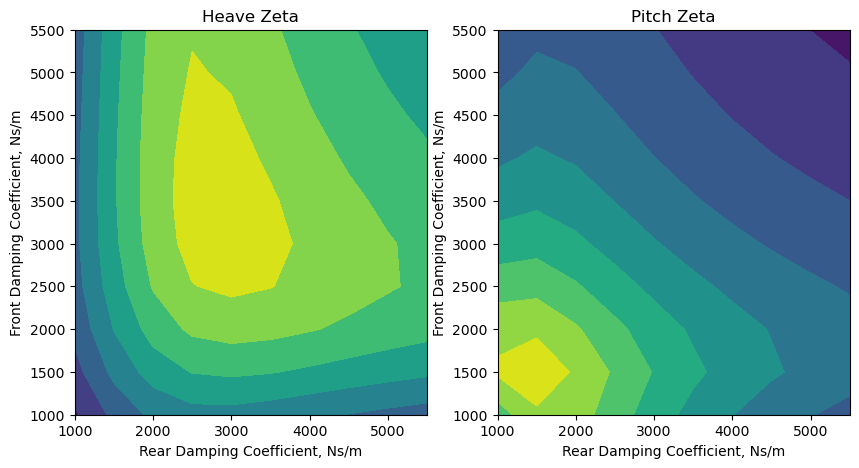

In [74]:

damping_sweep = np.arange(500, 5001, 250)

size = len(damping_sweep)


heave_zeta_array = np.zeros((size,size))
pitch_zeta_array = np.zeros((size,size))

for i in range(size):
    for j in range(size):
        

        A = np.array([
            [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
            [
                -(k_wf + k_wr) / m_s,
                (a * k_wf - b * k_wr) / m_s,
                k_wf / m_s,
                k_wr / m_s,
                -(c_wf + c_wr) / m_s,
                (a * c_wf - b * c_wr) / m_s,
                c_wf / m_s,
                c_wr / m_s
            ],
            [
                (a * k_wf - b * k_wr) / I_yy,
                -(a**2 * k_wf + b**2 * k_wr) / I_yy,
                -a * k_wf / I_yy,
                b * k_wr / I_yy,
                (a * c_wf - b * c_wr) / I_yy,
                -(a**2 * c_wf + b**2 * c_wr) / I_yy,
                -a * c_wf / I_yy,
                b * c_wr / I_yy
            ],
            [
                k_wf / m_uf,
                -a * k_wf / m_uf,
                -(k_wf + k_tf) / m_uf,
                0.0,
                c_wf / m_uf,
                -a * c_wf / m_uf,
                -(c_wf + c_tf) / m_uf,
                0.0
            ],
            [
                k_wr / m_ur,
                b * k_wr / m_ur,
                0.0,
                -(k_wr + k_tr) / m_ur,
                c_wr / m_ur,
                b * c_wr / m_ur,
                0.0,
                -(c_wr + c_tr) / m_ur
            ]
        ])
        
        [heave_mode, pitch_mode] = get_modes(A)[0:2]
        heave_zeta_array[i][j] = heave_mode[1]
        pitch_zeta_array[i][j] = pitch_mode[1]


import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.contourf(damping_sweep, damping_sweep, heave_zeta_array)
plt.xlabel("Rear Damping Coefficient, Ns/m")
plt.ylabel("Front Damping Coefficient, Ns/m")
plt.title("Heave Zeta")

plt.subplot(122)
plt.contourf(damping_sweep, damping_sweep, pitch_zeta_array)
plt.xlabel("Rear Damping Coefficient, Ns/m")
plt.ylabel("Front Damping Coefficient, Ns/m")
plt.title("Pitch Zeta")





由上图不难看出，两个车身模态的阻尼比均在调节范围内有理论最优值。如前文所述，在赛道较平整的中美赛区我们更需要关注的是车身的俯仰模态，于是可以得到其俯仰模态阻尼比最大化的$1500-2500Ns/m$范围为该车的大致客观最优阻尼范围。